# FF Volatility Prediction

## Notebook Overview


The goal of this session is to construct a **variance prediction model**.  More specifically your task is to predict the 10-minute variance of a stock given time-series data for the _previous_ 10 minutes such that the root mean squared error (RMSE) is minimised.

To help you do that, this notebook contains:
- Definitions of the data you have access to
- A simple baseline prediction model and a RMSE evaluation function
- Some ideas and hints on how to build your own, better, model
- A section to submit your predictions
- Some theoretical notes for reference on the content

Note: we are using variance as the target instead of volatility because options PnL from stock movement is roughly linear with variance.


## Source Data
You will be loading in two pandas objects. The data covers multiple stocks sampled randomly over a ~two year time horizon.

`df`: a DataFrame containing the stock order-book data. Columns:

- `stock_id` - identifier for the stock
- `time_id` - ID code for the time bucket. Time IDs are not necessarily sequential and one time_id is 10 minutes. Time IDs correspond to the same period across stocks (e.g., time_id 5 is the same period of time in stock 1 and 2)
- `seconds_in_bucket` - Number of seconds from the start of the bucket (time_id), always starting from 0. Some seconds are missing because nothing changed in that second
- `bid_price`, `ask_price` - Normalized best bid (buy) and ask (sell) prices
- `bid_size`, `ask_size` - The number of shares on the best bid (buy) and ask (sell) levels
- `weighted_average_price` - Volume-weighted mid price derived from the bid/ask
- `log_return` - Log return between consecutive weighted average prices within each time bucket (NaN for the first row)

`target_vars`: a Series indexed by `(stock_id, time_id)` containing the target variances for training.

- `target` - the variance of the stock in the 10 minutes following the corresponding `(stock_id, time_id)` data in `df`
 
Note that some `(stock_id, time_id)` pairs are missing from the targets.
Your goal is to submit a prediction for these missing instances. We will then check this to see how you have gone. Use the known targets to train your model, whatever it may be. Good luck! 

In [1]:
!pip install pyarrow
!pip install fastparquet
!pip install matplotlib

from variance_prediction_library import (
    load_data,
    load_targets,
    evaluate_predictions,
)


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
df = load_data()
target_vars = load_targets()


Let's look at the data:


In [3]:
df

,stock_id,time_id,seconds_in_bucket,bid_price,ask_price,bid_size,ask_size,weighted_average_price,log_return
0,0,0,0,17.987354,18.006899,100,300,17.992240,NaN
1,0,0,1,17.987354,18.006899,100,313,17.992087,-0.000009
2,0,0,2,17.990803,18.010347,33,158,17.994180,0.000116
3,0,0,3,17.990803,18.010347,33,100,17.995652,0.000082
4,0,0,4,17.995401,18.006899,100,100,18.001150,0.000305
...,...,...,...,...,...,...,...,...,...
1562722,4,956,588,48.844769,48.887527,346,100,48.877940,-0.000029
1562723,4,956,592,48.844769,48.887527,356,100,48.878151,0.000004
1562724,4,956,594,48.844769,48.887527,346,200,48.871865,-0.000129
1562725,4,956,595,48.844769,48.870796,346,100,48.864960,-0.000141


In [ ]:
df[df.stock_id==0]

,stock_id,time_id,seconds_in_bucket,bid_price,ask_price,bid_size,ask_size,weighted_average_price,log_return
0,0,0,0,17.987354,18.006899,100,300,17.992240,NaN
1,0,0,1,17.987354,18.006899,100,313,17.992087,-0.000009
2,0,0,2,17.990803,18.010347,33,158,17.994180,0.000116
3,0,0,3,17.990803,18.010347,33,100,17.995652,0.000082
4,0,0,4,17.995401,18.006899,100,100,18.001150,0.000305
...,...,...,...,...,...,...,...,...,...
323030,0,956,590,18.091612,18.095135,100,305,18.092482,-0.000313
323031,0,956,592,18.091612,18.095135,50,366,18.092035,-0.000025
323032,0,956,596,18.091612,18.095135,150,305,18.092773,0.000041
323033,0,956,597,18.091612,18.095135,170,305,18.092873,0.000005


Let's look at the target variances we have:


In [ ]:
target_vars

stock_id  time_id
0         0          0.000011
          1          0.000065
          4          0.000008
          6          0.000011
          8          0.000003
                       ...   
4         951        0.000005
          952        0.000014
          954        0.000035
          955        0.000003
          956        0.000049
Name: target, Length: 3975, dtype: float64

In [ ]:
target_vars[0]

time_id
0      0.000011
1      0.000065
4      0.000008
6      0.000011
8      0.000003
         ...   
951    0.000002
952    0.000008
954    0.000005
955    0.000003
956    0.000014
Name: target, Length: 795, dtype: float64

As mentioned, some `(stock_id, time_id)` pairs are missing from the targets! Let's build a model on the ones that we know:


In [ ]:
known_prediction_index = target_vars.index
known_prediction_index

MultiIndex([(0,   0),
            (0,   1),
            (0,   4),
            (0,   6),
            (0,   8),
            (0,   9),
            (0,  10),
            (0,  12),
            (0,  14),
            (0,  15),
            ...
            (4, 945),
            (4, 946),
            (4, 948),
            (4, 949),
            (4, 950),
            (4, 951),
            (4, 952),
            (4, 954),
            (4, 955),
            (4, 956)],
           names=['stock_id', 'time_id'], length=3975)

### How is Volatility Calculated?

The volatility of the second 10-minutes of each (10 minute, 10 minute) pair is calculated as follows:

$$
\sigma = \sqrt{\sum_{t}r_{t}^2}
$$

and for variance
$$
\sigma^2 = \sum_{t}r_{t}^2
$$

Where $r$ is the _log_return_ between the previous data point and the current one. Note that the _log_return_ cannot be calculated for the first data point in each hour, in which case the _log_return_ will be the special value _NaN_ (not-a-number).

Another useful relationship if we want to use different time intervals is the following:
$$
\sigma_{1}^{2} = \sigma_{2}^{2} \cdot \frac{t_{1}}{t_{2}}
$$

You don't need to use this relationship, as all the `target_vars` are 10 minute variances and the orderbook data preceeding it is 10minutes in length. However it becomes important if you start working with returns that don't sum to 10 minutes in duration.


#### Built-in Model

We provide a simple model to get started. This simple prediction model is just going to be the calculated variance of the last 10 minutes for each `(stock_id, time_id)` as your prediction for the target (the next 10 minutes). This will give you a baseline going forward from which to improve.

#### Step-by-step: What the baseline model does

The baseline model computes volatility for each 10 minute bucket i.e., each `(stock_id, time_id)` as:

1) Take all rows within that 10 minutes for a given stock
2) Drop `NaN` values in `log_return` (the first row has no previous price)
3) Compute the variance


Let's look at the raw data for a single `(stock_id, time_id)`:


In [8]:
single_stock_id, single_time_id = known_prediction_index[0]
# We will use shorthand of df_tid to represent the dataframe for a single (stock_id, time_id)
df_tid = df[(df["stock_id"] == single_stock_id) & (df["time_id"] == single_time_id)].copy()
df_tid[["stock_id", "time_id", "seconds_in_bucket", "weighted_average_price", "log_return"]].head(10)

,stock_id,time_id,seconds_in_bucket,weighted_average_price,log_return
0,0,0,0,17.992240,NaN
1,0,0,1,17.992087,-0.000009
2,0,0,2,17.994180,0.000116
3,0,0,3,17.995652,0.000082
4,0,0,4,18.001150,0.000305
5,0,0,5,17.999234,-0.000106
6,0,0,9,18.013078,0.000769
7,0,0,10,18.009773,-0.000183
8,0,0,12,18.009198,-0.000032
9,0,0,13,18.009773,0.000032


Drop the `log_return` value that is `NaN` in this half-hour:


In [9]:
vals = df_tid["log_return"].dropna()

Compute the variance for this one `(stock_id, time_id)`:


In [10]:
var = float((vals ** 2).sum()) if not vals.empty else 0.0
var


1.940351261969183e-05

The above can be written as a function, `_var_unweighted`

In [11]:
import pandas as pd
from typing import List

# This function declaration makes clear the inputs and outputs, structured as: 
# def func_name(arg1: type(arg1)) -> type(return value)
def _var_unweighted(group: pd.DataFrame) -> float:
    """Unweighted variance: sum of squared log returns.

    Returns the unweighted variance for a single (stock_id, time_id)
    """
    log_returns = group["log_return"].dropna()
    return float((log_returns ** 2).sum()) if not log_returns.empty else 0.0


Naturally we want to use `_var_unweighted` to calculate a variance for each `(stock_id, time_id)`. For this we need new tools, `groupby` and `apply`.


``` python
gdf = df.groupby(["stock_id", "time_id"], sort=True)
```

This splits the dataframe into groups, one group for each `(stock_id, time_id)` pair. After this step, `gdf` isn’t a normal dataframe anymore, it’s a special object that represents a collection of sub-dataframes, each with rows from a single stock and time bucket. Somewhat similar to a dictionary.

``` python
all_vars = gdf.apply(lambda grp: _var_unweighted(grp), include_groups=False)
```

Here, apply runs the function `_var_unweighted` separately on each group.

- `grp` is just a normal dataframe containing the rows for one particular `(stock_id, time_id)`.
- `_var_unweighted(grp)` computes the variance for that group.
- `apply` collects all these results and returns a Series, where the index is `(stock_id, time_id)` and the values are the variances.

In [12]:
def predict_baseline(df: pd.DataFrame, prediction_index: pd.MultiIndex) -> pd.Series:
    """Predict variance per (stock_id, time_id) using the standard formula."""
    gdf = df.groupby(["stock_id", "time_id"], sort=True)
    all_vars = gdf.apply(lambda grp: _var_unweighted(grp), include_groups=False)
    return all_vars.loc[prediction_index]

predicted_vars = predict_baseline(df, known_prediction_index)
predicted_vars


stock_id  time_id
0         0          0.000019
          1          0.000108
          4          0.000005
          6          0.000026
          8          0.000004
                       ...   
4         951        0.000005
          952        0.000012
          954        0.000009
          955        0.000007
          956        0.000020
Length: 3975, dtype: float64

Let's put all the code to create and test our model into one cell. You can use this as a template for setting up your own model later. Note `evaluate_predictions` lets us see how good our prediction is, returning a RMSE number we can directly compare between models (remember, smaller RMSE is better).

0.0056103

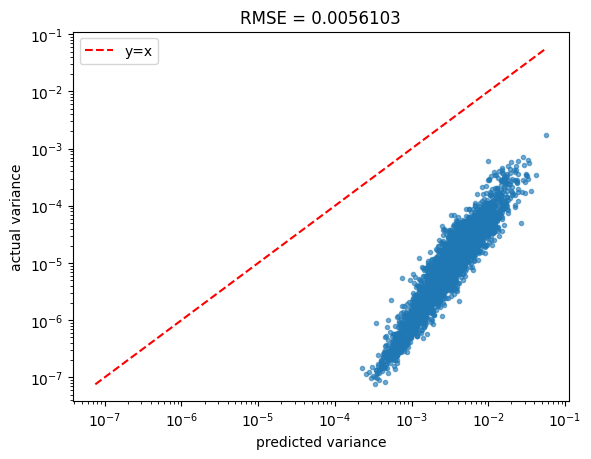

In [13]:
def _var_unweighted(group: pd.DataFrame) -> float:
    """Unweighted variance: sum of squared log returns.

    Returns the unweighted variance for a single (stock_id, time_id)
    """
    log_returns = group["log_return"].dropna()
    return float(((log_returns ** 2).sum()) ** (0.5)) if not log_returns.empty else 0.0

def predict_baseline(df: pd.DataFrame, prediction_index: pd.MultiIndex) -> pd.Series:
    """Predict variance per (stock_id, time_id) using the standard formula."""
    gdf = df.groupby(["stock_id", "time_id"], sort=True)
    all_vars = gdf.apply(lambda grp: _var_unweighted(grp), include_groups=False)
    return all_vars.loc[prediction_index]

predicted_vars = predict_baseline(df, known_prediction_index)
evaluate_predictions(predicted_vars, target_vars, plot=True, log_axes=True)


### A Mistake!

Oops, our predictions on the plot above are orders of magnitude off. We must have made a mistake, can you find it? Hint: the error is logical, not Python knowledge based

### Improving the Naive Prediction

Ok! Now you've figured out that issue, what are some ways to improve our prediction?


#### Idea 1: Use Only the Most Relevant Sample Data?

Each 10 minute window has up to 600 rows. We could ignore the earliest ones and use only the last rows. Remember though, our target is 10 minute variance, so we need to rescale our < 10min var to a 10min var




#### Idea 2: Use Weighted Returns?

The variance near the end of the sample period should be close to the variance in the target period. We can weight later rows more heavily.

$$
\sigma^2 = \sum_{t}w\times r_{t}^2
$$

where $\sum_{t}w = 1$. The _seconds_in_bucket_ data point provides a convenient way to construct a linear weighting scheme, but we must remember to normalise the weights. Would an exponential weighting scheme perform even better?


#### Idea 3: Something else?

You can develop whatever model you want. We do have some other hints though


### Hints
- You need to choose a good model. You only have limited time and a simple submission that works is better than a complex one that doesn't.
- If you were to focus in on any particularly datapoints, which ones affect your RMSE the most? Any pattern to those? 
- Overfitting is a real risk

Advanced tips:
- Are the 10minute buckets completely independent? Are the stocks independent? Could we use this to our advantage?
- If you want to try machine learning, tranforming the target to log(var) will make the target more normal which these models tend to like. Though, don't forget to transform back when submitting or using our evaluator


### Now it's Your Turn.


In [14]:
def predict_YOUR_MODEL_HERE(df, prediction_index):
    return

In [16]:
df.head()

,stock_id,time_id,seconds_in_bucket,bid_price,ask_price,bid_size,ask_size,weighted_average_price,log_return
0,0,0,0,17.987354,18.006899,100,300,17.992240,NaN
1,0,0,1,17.987354,18.006899,100,313,17.992087,-0.000009
2,0,0,2,17.990803,18.010347,33,158,17.994180,0.000116
3,0,0,3,17.990803,18.010347,33,100,17.995652,0.000082
4,0,0,4,17.995401,18.006899,100,100,18.001150,0.000305


In [17]:
df[df['time_id'] == 0].groupby('stock_id').scatter(y = 'weighted_average_price', x = 'seconds_in_bucket')

AttributeError: 'DataFrameGroupBy' object has no attribute 'scatter'

## Submission


Run the below cell, changing `predict_YOUR_MODEL_HERE()` to the name of your model

In [15]:
all_pairs = pd.MultiIndex.from_frame(
    df[["stock_id", "time_id"]].drop_duplicates().sort_values(["stock_id", "time_id"]),
)
missing_prediction_index = all_pairs.difference(target_vars.index)
predicted_vars_TO_SUBMIT = predict_YOUR_MODEL_HERE(df, missing_prediction_index)

import csv

with open('my_submission.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['stock_id', 'time_id', 'prediction'])
    for (stock_id, time_id), value in predicted_vars_TO_SUBMIT.items():
        writer.writerow([stock_id, time_id, value])


AttributeError: 'NoneType' object has no attribute 'items'

### Explanatory Notes

Below are some explanatory notes about the stock data used in this workshop. Can you use this information to make a better variance prediction?

#### The Order Book

Traders in a stock market place _orders_, each of which is a request to buy or sell a certain number of shares in a stock at a certain price. Taken together, the current orders can be viewed as an _Order Book_ which shows the total number of shares (a.k.a. volume) that traders are willing to buy or sell at each price level. For example:

| Bid Volume | Price | Sell Volume |
| ---------: | :---: | :---------- |
|            |  151  |  196        |
|            |  150  |  189        |
|            |  149  |  148        |
|            |  148  |  221        |
|       251  |  147  |             |
|       321  |  146  |             |
|       300  |  145  |             |
|        20  |  144  |             |

In this example, there are traders willing to sell at a price of 148 and the total number of shares they are willing to sell at that price is 221. Similarly there are traders willing to buy up to 321 shares at a price of 146.

We number the buy (bid) prices from highest to lowest and the sell (ask) prices from lowest to highest. In our data, `bid_price` is the highest buy price in the order book and `ask_price` is the lowest sell price.


#### Weighted Average Price

We can use the order book to get a sense of the _current_ price by taking an average of the prices at which traders are willing to trade, weighted by the volume at each price level.

A simple weighted average would, however, be misleading. To understand why, suppose there were many buyers and few sellers. In that case the buy (lower) prices would have greater weight than the sell (higher) prices, pulling the weighted average down. But if there are more buyers than sellers, we would expect the price to go up, not down.

Therefore, the formula we use for the average price is:

$$
\frac{\mathit{BidPrice}\times\mathit{AskSize} + \mathit{AskPrice}\times\mathit{BidSize}}{\mathit{BidSize} + \mathit{AskSize}}
$$


#### Returns

Traders naturally want to know whether they are making a profit or a loss on their investments. The _return_ over a period of time is simply the price at the end of that period divided by the price at the beginning.

Returns are widely used in finance, however _log returns_ are preferred whenever some mathematical modelling is required. If $t_1$ and $t_2$ are two points in time, then the _log return_ from $t_1$ to $t_2$ is:

$$
r_{t_1, t_2} = \log \left(\frac{\mathit{WeightedAveragePrice}_{t_2}}{\mathit{WeightedAveragePrice}_{t_1}} \right)
$$

Log returns have several advantages including, for example:
- they are additive across time $r_{t_1, t_2} + r_{t_2, t_3} = r_{t_1, t_3}$
- regular returns cannot go below -100%, while log returns are not bounded.

Note: in most of the notebook we write $r_{t_1, t_2}$ as $r_{t}$ for readability